In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#### Carregamento de dados

In [4]:
df = pd.read_csv("../assets/ai4i2020.csv")
df.head(5)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Drop de features desnecessárias

In [5]:
df = df.drop(columns=["UDI", "Product ID"], axis = 0)
df.head(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Processamento dos dados

### Padronização de colunas float

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

scaler = StandardScaler()
features_float = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

df[features_float] = scaler.fit_transform(df[features_float])

lb = LabelEncoder()

df['Type'] = lb.fit_transform(df['Type'])

df.head(5)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0,0,0,0,0,0
1,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0,0,0,0,0,0
2,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0,0,0,0,0,0
3,1,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0,0,0,0,0,0
4,1,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0,0,0,0,0,0


#### Drop de colunas com tipificação do erro

In [7]:
df = df.drop(["TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)
df.head(3)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,1,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0


#### Modelagem do problema

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("Machine failure", axis = 1)
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 26, stratify = y)

## Regressão Logística

In [9]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state = 26, max_iter = 10000, class_weight = "balanced")

logreg.fit(X_train, y_train)

logreg_pred = logreg.predict(X_test)

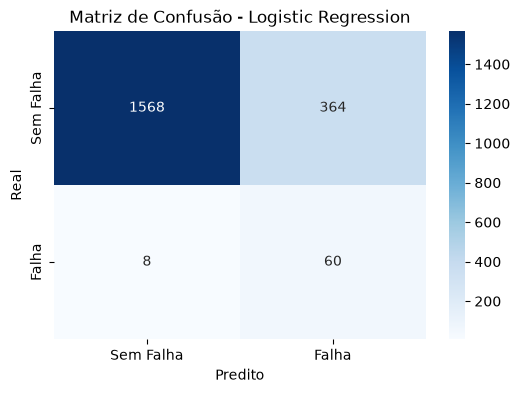

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sem Falha", "Falha"],
    yticklabels=["Sem Falha", "Falha"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

#### Resultados Matriz Confusão

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, logreg_pred).ravel()

# Métricas
accuracy = accuracy_score(y_test, logreg_pred)
precision = precision_score(y_test, logreg_pred)
recall = recall_score(y_test, logreg_pred)

# Especificidade 
specificity = tn / (tn + fp)

f1 = f1_score(y_test, logreg_pred)

print(f"Acurácia:       {accuracy:.4f}")
print(f"Precisão:       {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"Especificidade: {specificity:.4f}")
print(f"F1-score:       {f1:.4f}")

Acurácia:       0.8140
Precisão:       0.1415
Recall:         0.8824
Especificidade: 0.8116
F1-score:       0.2439


#### F1-Score

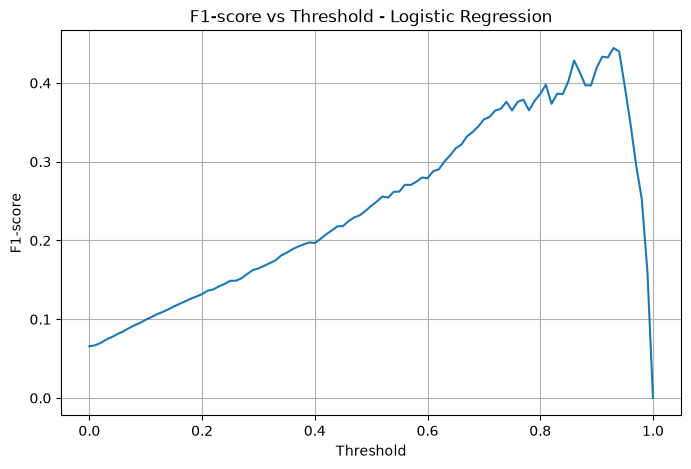

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

thresholds = np.arange(0.0, 1.01, 0.01)

logreg_prob = logreg.predict_proba(X_test)[:,1]

f1_scores = []

for threshold in thresholds:
    pred = (logreg_prob >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, pred))


plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_scores
)

plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold - Logistic Regression")

plt.grid(True)
plt.show()

### Novo Threshold Probabilístico para maior f1-score (Média harmônica entre precisão e recall)

In [13]:

# 1. Treina o modelo (como você já fez)
logreg = LogisticRegression(random_state=26, max_iter=10000, class_weight="balanced")
logreg.fit(X_train, y_train)

# 2. Em vez de prever a classe direta, pegue as probabilidades
logreg_probs = logreg.predict_proba(X_test)[:, 1]

# 3. Defina o novo threshold com base no seu gráfico
novo_threshold = 0.93

logreg_pred_custom = (logreg_probs >= novo_threshold).astype(int)

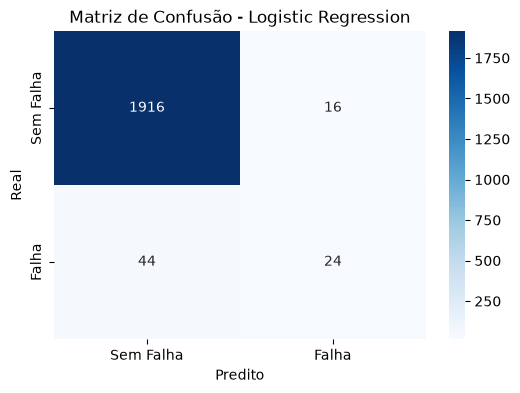

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logreg_pred_custom)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sem Falha", "Falha"],
    yticklabels=["Sem Falha", "Falha"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Logistic Regression")
plt.show()

In [15]:
# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, logreg_pred_custom).ravel()

# Métricas
accuracy = accuracy_score(y_test, logreg_pred_custom)
precision = precision_score(y_test, logreg_pred_custom)
recall = recall_score(y_test, logreg_pred_custom)
specificity = tn / (tn + fp)

f1 = f1_score(y_test, logreg_pred_custom)

print(f"Acurácia:       {accuracy:.4f}")
print(f"Precisão:       {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"Especificidade: {specificity:.4f}")
print(f"F1-score:       {f1:.4f}")

Acurácia:       0.9700
Precisão:       0.6000
Recall:         0.3529
Especificidade: 0.9917
F1-score:       0.4444


Fazendo uma análise dos resultados da Regressão Logística até agora, foi mostrado que, no cenário inicial (threshold 0.5), o modelo obteve 88,24% de Recall, mas uma Precisão de apenas 14,15% (excesso de alarmes falsos). Ao elevar o limiar para buscar o topo do F1-score, a Precisão subiu para 60%, mas o Recall despencou para 35,29%, na prática, apenas 24 de 68 falhas reais foram detectadas, deixando a fábrica vulnerável.

Como falhas em sensores de IoT raramente seguem padrões linearese apesar de existirem técnicas de geração de dados sintéticos (como SMOTE) pudessem mitigar o desbalanceamento, estou optando para mudar para o algorítimo Random Forest. Pois ele tem uma capacidade nativa de mapear relações não-lineares complexas permita trabalhar com um limiar probabilístico mais seguro, capturando as falhas (Recall alto) sem inviabilizar a operação com alarmes falsos (Precisão balanceada).

## Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 26, class_weight = "balanced", n_estimators = 100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Matriz Confusão

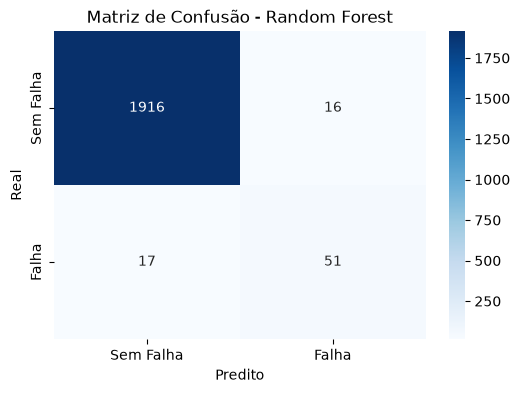

In [19]:

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Sem Falha", "Falha"],
    yticklabels=["Sem Falha", "Falha"]
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

### Resultados

In [21]:
# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

# Métricas
accuracy = accuracy_score(y_test, rf_pred)
precision = precision_score(y_test, rf_pred)
recall = recall_score(y_test, rf_pred)
specificity = tn / (tn + fp)

f1 = f1_score(y_test, rf_pred)

print(f"Acurácia:       {accuracy:.4f}")
print(f"Precisão:       {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"Especificidade: {specificity:.4f}")
print(f"F1-score:       {f1:.4f}")

Acurácia:       0.9835
Precisão:       0.7612
Recall:         0.7500
Especificidade: 0.9917
F1-score:       0.7556


A migração para o algoritmo Random Forest trouxe um salto expressivo de desempenho em relação à Regressão Logística com limiar ajustado. Enquanto a Regressão Logística sacrificava a segurança da operação ao registrar apenas 35,29% de Recall (deixando passar 65% das falhas), o Random Forest alcançou um excelente equilíbrio para o cenário de IoT: elevou o Recall para 75,00% e, simultaneamente, subiu a Precisão para 76,12%. Esse ajuste refinado fez o F1-score disparar de 0,4444 para 0,7556, reduzindo drasticamente tanto as quebras inesperadas quanto os alarmes falsos.

Como o Random Forest possui uma tendência natural a memorizar os dados de treino, o próximo passo técnico consiste em avaliar se o modelo está sofrendo de overfitting. Para isso, será aplicada a técnica de Validação Cruzada (Cross-Validation) dividida em 5 partes (k-fold = 5), garantindo que o desempenho se mantenha estável e homogêneo em diferentes partições da base de dados.

### Cross Validation

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_train, y_train, cv = 5, scoring = "f1")

#Resultados
resultados = []
for i, score in enumerate(scores, 1):
    print(f"F1-score, parte {i}: {score:.2f}")
    resultados.append(score)

print(f"Média do F1-score: {np.mean(resultados):.2f}")
print(f"Desvio padrão do F1-score: {np.std(resultados):.2f}")

F1-score, parte 1: 0.69
F1-score, parte 2: 0.61
F1-score, parte 3: 0.73
F1-score, parte 4: 0.61
F1-score, parte 5: 0.76
Média do F1-score: 0.68
Desvio padrão do F1-score: 0.06


### Interesse e Objetivo (Minimizar Custo com Manutenção)

- Falso Negativo("Tem falha e o modelo infere como sem falha")
- Falso Positivo("Modelo infere que haverá falha mas não tem falha")

Falso Positivo (Mais Barato)

Falso Negativo (Mais Caro)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Extrai as probabilidades
rf_probs = rf.predict_proba(X_test)[:, 1]

thresholds_resultados = []

# Correção: np.arange com um 'r' apenas
for p in np.arange(0.0, 1.01, 0.05):

    # Aplica o threshold atual
    pred_custon = (rf_probs >= p).astype(int)

    # Extrai a matriz de confusão para calcular a especificidade do corte atual
    tn, fp, fn, tp = confusion_matrix(y_test, pred_custon).ravel()

    accuracy = accuracy_score(y_test, pred_custon)
    precision = precision_score(y_test, pred_custon, zero_division=0)
    recall = recall_score(y_test, pred_custon)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_test, pred_custon)

    thresholds_resultados.append({
        'Threshold': round(p, 2),
        'Acurácia': round(accuracy, 4),
        'Precisão': round(precision, 4),
        'Recall': round(recall, 4),
        'Especificidade': round(specificity, 4),
        'F1-score': round(f1, 4)
    })

df_limiares = pd.DataFrame(thresholds_resultados)
print(df_limiares.to_string(index=False))

 Threshold  Acurácia  Precisão  Recall  Especificidade  F1-score
      0.00    0.0340    0.0340  1.0000          0.0000    0.0658
      0.05    0.8850    0.2264  0.9853          0.8815    0.3681
      0.10    0.9185    0.2889  0.9559          0.9172    0.4437
      0.15    0.9445    0.3757  0.9559          0.9441    0.5394
      0.20    0.9510    0.4038  0.9265          0.9519    0.5625
      0.25    0.9635    0.4803  0.8971          0.9658    0.6256
      0.30    0.9725    0.5619  0.8676          0.9762    0.6821
      0.35    0.9770    0.6146  0.8676          0.9808    0.7195
      0.40    0.9800    0.6628  0.8382          0.9850    0.7403
      0.45    0.9830    0.7125  0.8382          0.9881    0.7703
      0.50    0.9840    0.7571  0.7794          0.9912    0.7681
      0.55    0.9830    0.7742  0.7059          0.9928    0.7385
      0.60    0.9855    0.8545  0.6912          0.9959    0.7642
      0.65    0.9845    0.8627  0.6471          0.9964    0.7395
      0.70    0.9825    0

Para escolha do modelo de previsão, fixarei o limiar de decisão do Random Forest em 0.45. Essa escolha prioriza a segurança operacional da fábrica ao elevar o Recall para 83.82% garantindo que o número a maioria dos defeitos de máquina sejam identificados antes de parar a produção.

Graças ao poder de separação do Random Forest, esse ganho em segurança foi obtido mantendo uma Precisão robusta de 71.25%, o que evita o excesso de alarmes falsos e garante a confiabilidade dos alertas para a equipe de manutenção.

### Salva o Modelo Random Forest

In [28]:
import joblib
import os


joblib.dump(rf, '../models/modelo_confiabilidade_rf.pkl')
print("Modelo do Random Forest exportado com sucesso!")

Modelo do Random Forest exportado com sucesso!
